## Analyse Exploratoire des Données - Prédiction du Churn Bancaire

In [49]:
# Import necessary libraries
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

from statsmodels.stats.outliers_influence import variance_inflation_factor

from scipy.stats import kstest # for Kolmogorov-Smirnov test
from scipy.stats import f_oneway # for ANOVA test
from scipy.stats import chi2_contingency # for Chi-square test
import itertools # for combinations 

---
Chargement et Inspection des Données
---

In [50]:
# Load the dataset
df_train = pd.read_csv('../data/Data.csv')

In [51]:
# Explore the dataset
# Display the first few rows of the dataset
df_train.head()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


In [52]:
# Display the shape of the dataset
df_train.shape

(5960, 13)

In [53]:
# Display the data types of the columns
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   object 
 5   JOB      5681 non-null   object 
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), object(2)
memory usage: 605.4+ KB


In [54]:
# Display the percentage of missing values in each column
df_train.isna().mean()*100  

BAD         0.000000
LOAN        0.000000
MORTDUE     8.691275
VALUE       1.879195
REASON      4.228188
JOB         4.681208
YOJ         8.640940
DEROG      11.879195
DELINQ      9.731544
CLAGE       5.167785
NINQ        8.557047
CLNO        3.724832
DEBTINC    21.258389
dtype: float64

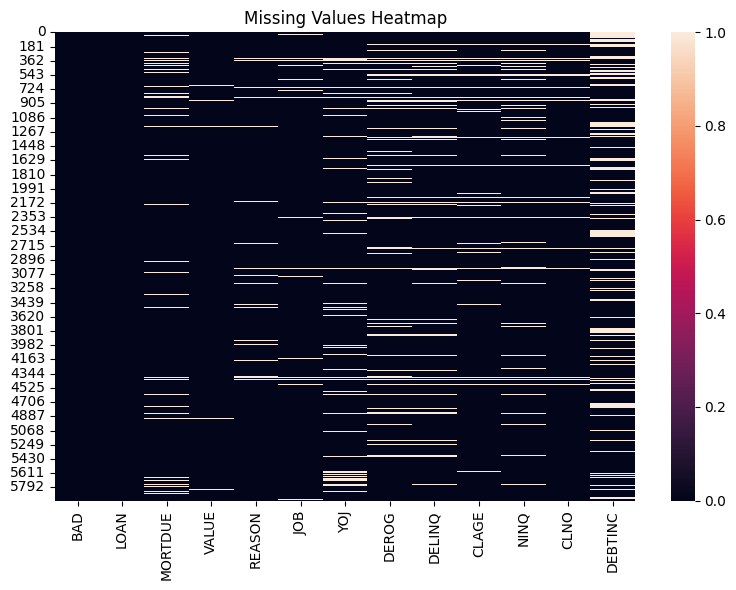

In [55]:
# Visualize missing values heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_train.isnull(), cbar=True)
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

In [56]:
# Display the sum of duplicated 
df_train.duplicated().sum()

0

---
Target
---


La variable **BAD** est notre cible:
- **0**: 
- **1**: 

In [57]:
# Select Target variable
#Y = df_train['Exited']
#df_train.drop(columns=['Exited'], inplace=True)

In [58]:
# Target variable 
df_train['BAD'].value_counts()

BAD
0    4771
1    1189
Name: count, dtype: int64

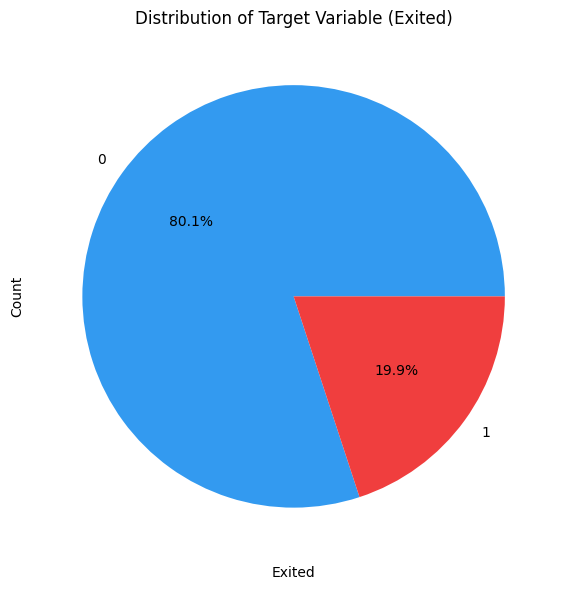

In [59]:
plt.figure(figsize=(8, 6))
df_train['BAD'].value_counts().plot(kind='pie',autopct='%1.1f%%', colors=['#339af0', '#f03e3e'])
plt.title('Distribution of Target Variable (Exited)')
plt.xlabel('Exited')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

---
Nettoyage et Préparation
---

In [60]:
# Drop unnecessary columns
#df_train.drop(['id','Surname','CustomerId'],axis=1, inplace=True)

In [61]:
# display the shape of the dataset after dropping columns
df_train.shape

(5960, 13)

In [62]:
# Select numerical variables
var_num = df_train.select_dtypes(include=['int', 'float'])
# Select categorical variables
var_cat = df_train.select_dtypes(include=['object','category'])

In [63]:
# Display the columns of numerical and categorical variables
display(var_num.columns)
display(var_cat.columns)

# Count of numerical and categorical variables
count_data_train = var_num + var_cat
display(count_data_train.shape)

Index(['BAD', 'LOAN', 'MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE',
       'NINQ', 'CLNO', 'DEBTINC'],
      dtype='object')

Index(['REASON', 'JOB'], dtype='object')

(5960, 13)

In [64]:
# Display descriptive statistics for numerical variables
print("Descriptive Statistics for Numerical Variables:")
display(var_num.describe().T)
# Display descriptive statistics for categorical variables
print("Descriptive Statistics for Categorical Variables:")
display(var_cat.describe().T)

Descriptive Statistics for Numerical Variables:


,count,mean,std,min,25%,50%,75%,max
BAD,5960.0,0.199497,0.399656,0.000000,0.000000,0.000000,0.000000,1.000000
LOAN,5960.0,18607.969799,11207.480417,1100.000000,11100.000000,16300.000000,23300.000000,89900.000000
MORTDUE,5442.0,73760.817200,44457.609458,2063.000000,46276.000000,65019.000000,91488.000000,399550.000000
VALUE,5848.0,101776.048741,57385.775334,8000.000000,66075.500000,89235.500000,119824.250000,855909.000000
YOJ,5445.0,8.922268,7.573982,0.000000,3.000000,7.000000,13.000000,41.000000
DEROG,5252.0,0.254570,0.846047,0.000000,0.000000,0.000000,0.000000,10.000000
DELINQ,5380.0,0.449442,1.127266,0.000000,0.000000,0.000000,0.000000,15.000000
CLAGE,5652.0,179.766275,85.810092,0.000000,115.116702,173.466667,231.562278,1168.233561
NINQ,5450.0,1.186055,1.728675,0.000000,0.000000,1.000000,2.000000,17.000000
CLNO,5738.0,21.296096,10.138933,0.000000,15.000000,20.000000,26.000000,71.000000


Descriptive Statistics for Categorical Variables:


,count,unique,top,freq
REASON,5708,2,DebtCon,3928
JOB,5681,6,Other,2388


In [65]:
# Count unique values in numerical variables
display(var_num.nunique())
# Count unique values in categorical variables
display(var_cat.nunique())

BAD           2
LOAN        540
MORTDUE    5053
VALUE      5381
YOJ          99
DEROG        11
DELINQ       14
CLAGE      5314
NINQ         16
CLNO         62
DEBTINC    4693
dtype: int64

REASON    2
JOB       6
dtype: int64

### Investigastion 

In [66]:
df_train['REASON'].value_counts()

REASON
DebtCon    3928
HomeImp    1780
Name: count, dtype: int64

In [67]:
df_train['JOB'].value_counts()

JOB
Other      2388
ProfExe    1276
Office      948
Mgr         767
Self        193
Sales       109
Name: count, dtype: int64

In [68]:
df_train['DEBTINC'].value_counts()

DEBTINC
37.113614    1
44.382578    1
31.614680    1
41.576701    1
41.395462    1
            ..
31.613930    1
39.244669    1
40.943866    1
30.444839    1
34.571519    1
Name: count, Length: 4693, dtype: int64

---
Analyse
---

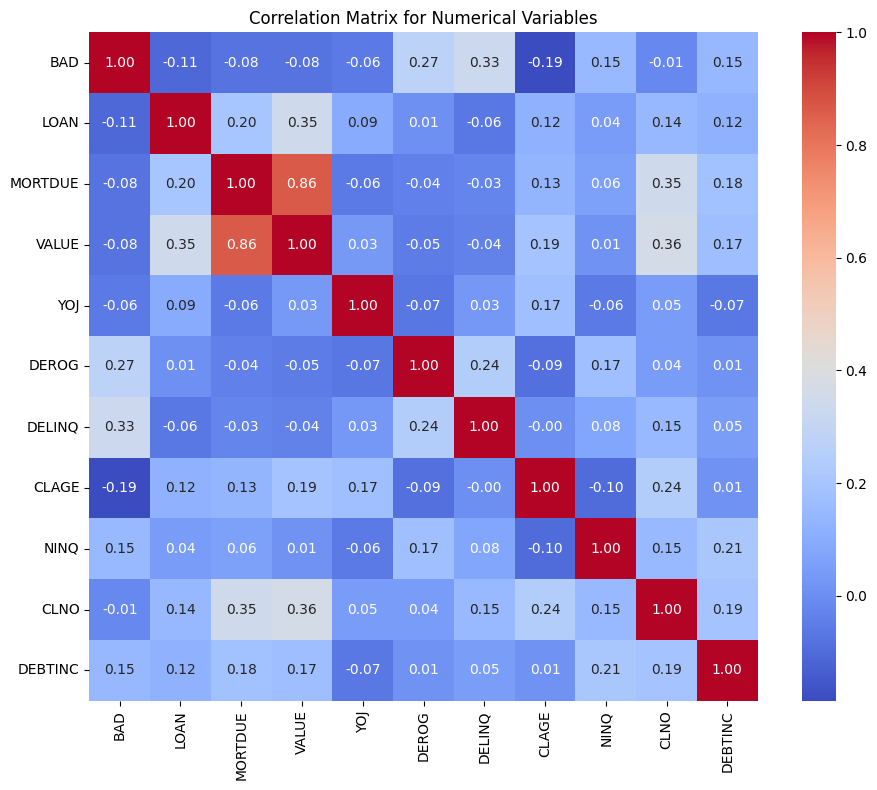

In [69]:
# Correlation matrix for numerical variables
plt.figure(figsize=(10, 8))
corr = var_num.corr('spearman')
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix for Numerical Variables')
plt.tight_layout()
plt.show()

In [70]:
var_num

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,3.0,0.0,0.0,93.333333,0.0,14.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
5955,0,88900,57264.0,90185.0,16.0,0.0,0.0,221.808718,0.0,16.0,36.112347
5956,0,89000,54576.0,92937.0,16.0,0.0,0.0,208.692070,0.0,15.0,35.859971
5957,0,89200,54045.0,92924.0,15.0,0.0,0.0,212.279697,0.0,15.0,35.556590
5958,0,89800,50370.0,91861.0,14.0,0.0,0.0,213.892709,0.0,16.0,34.340882


In [71]:
var_num = var_num.dropna

In [ ]:
def check_vif(X):
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data.sort_values('VIF', ascending=False)

# Check only numerical variables transformées et standardisées
vif_df = check_vif(var_num[['BAD','LOAN','VALUE']])

print("VIF values:")
print(vif_df)

TypeError: 'method' object is not subscriptable

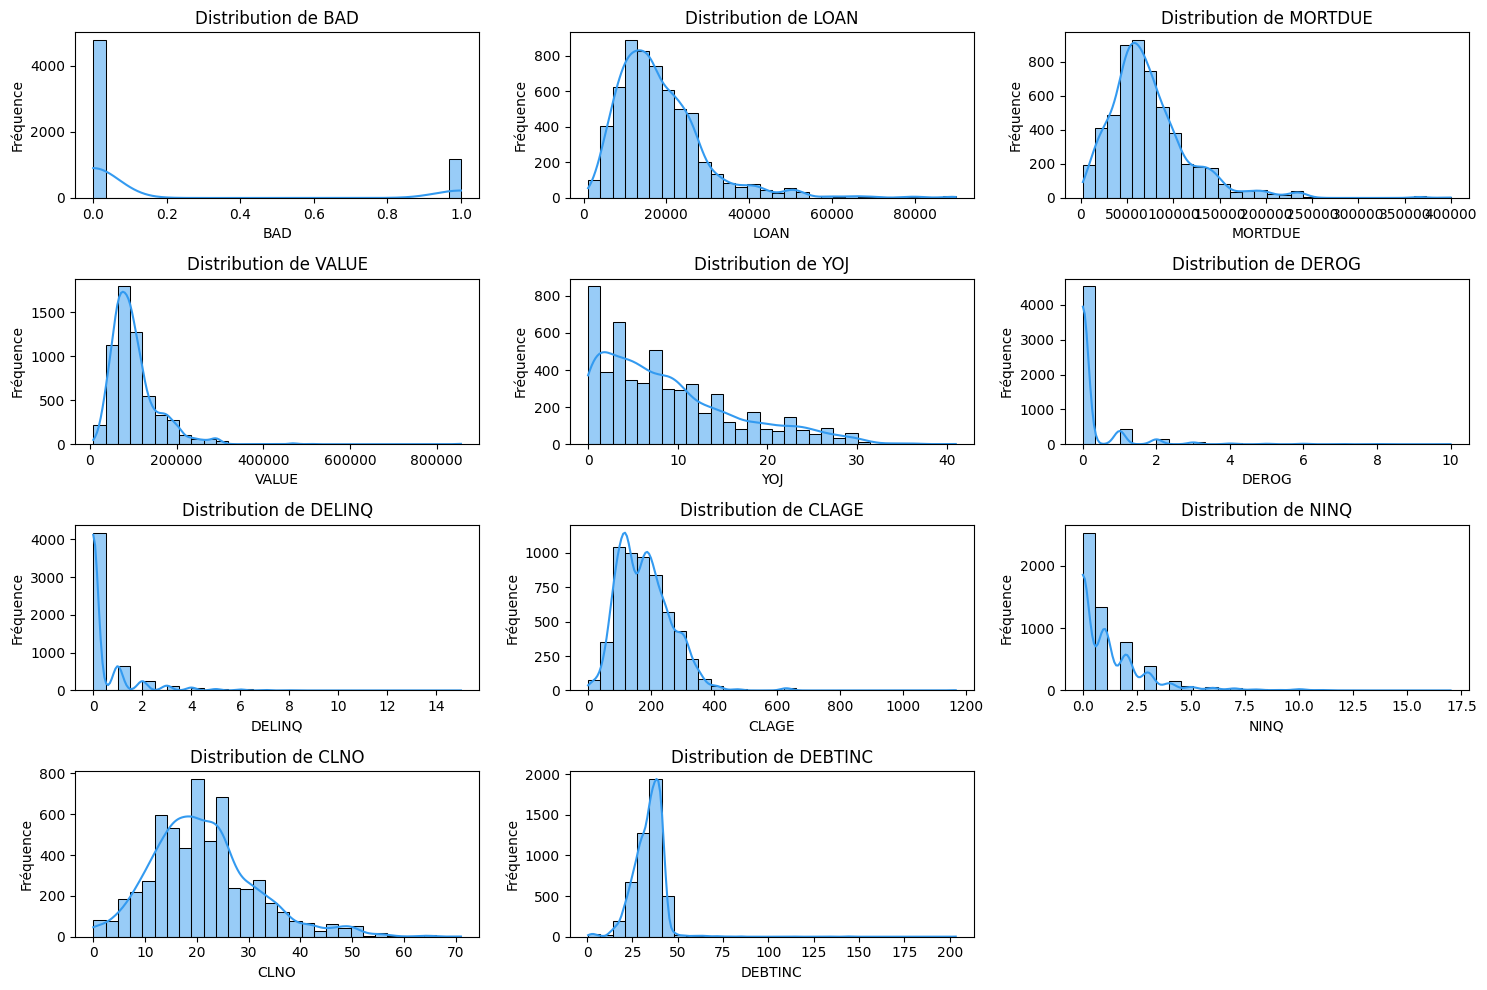

In [ ]:
# Display distribution of numerical variables

plt.figure(figsize=(15, 10))
for i, column in enumerate(var_num, 1):
    plt.subplot(4, 3, i)  # 3 lignes, 2 colonnes
    sns.histplot(var_num[column], kde=True, bins=30 , color='#339af0')
    plt.title(f'Distribution de {column}')
    plt.xlabel(column)
    plt.ylabel('Fréquence')

plt.tight_layout()
plt.show()

### Test de Normalité - Test de Kolmogorov-Smirnov (KS)

#### Théorème (Test KS):

Le **Test de Kolmogorov-Smirnov** compare une distribution empirique à une distribution théorique.

**Hypothèses du test:**
- **H₀** (Hypothèse Nulle): La variable suit une distribution normale
- **H₁** (Hypothèse Alternative): La variable ne suit **pas** une distribution normale

**Décision :**  
- Si *p-value* < 0.05 → **rejeter H0** → la distribution **n'est pas normale**
- Sinon → **ne pas rejeter H0** → la distribution **est normale**


In [ ]:
results = []

for col in var_num.columns:
    data = df_train[col].dropna()

    # Normalization 
    data_norm = (data - data.mean()) / data.std()

    # KS test vs normal distribution
    ks_stat, p_value = kstest(data_norm, 'norm')

    # Conclusion on normality
    is_normal = "Yes" if p_value >= 0.05 else "No"

    results.append([col, ks_stat, p_value, is_normal])

# Final results DataFrame
ks_df = pd.DataFrame(results, columns=["Variable", "KS_statistic", "p_value", "Is_Normal"])
ks_df

,Variable,KS_statistic,p_value,Is_Normal
0,BAD,0.491674,0.000000e+00,No
1,LOAN,0.096451,1.038385e-48,No
2,MORTDUE,0.105293,5.470849e-53,No
3,VALUE,0.128439,1.452053e-84,No
4,YOJ,0.121447,1.913456e-70,No
5,DEROG,0.480209,0.000000e+00,No
6,DELINQ,0.431709,0.000000e+00,No
7,CLAGE,0.064669,5.406766e-21,No
8,NINQ,0.252947,7.947557e-308,No
9,CLNO,0.077375,2.518537e-30,No


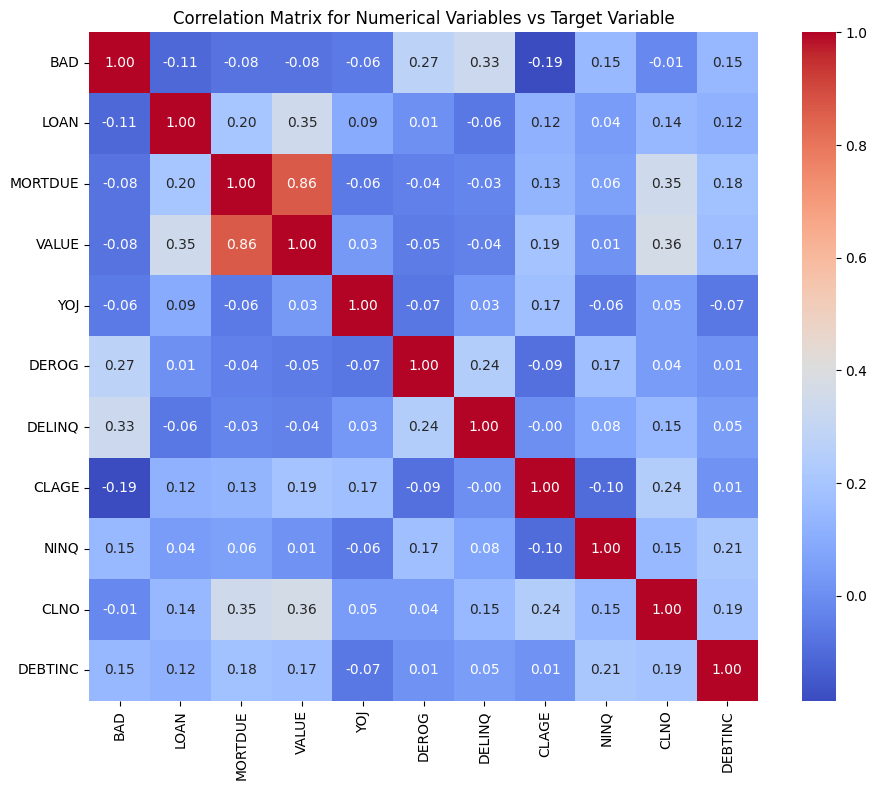

In [ ]:
# Correlation matrix for numerical variables vs target variable
plt.figure(figsize=(10, 8)) 

corr_target = var_num.copy()
corr_target['BAD'] = df_train['BAD']
corr = corr_target.corr('spearman')

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix for Numerical Variables vs Target Variable')
plt.tight_layout()
plt.show()

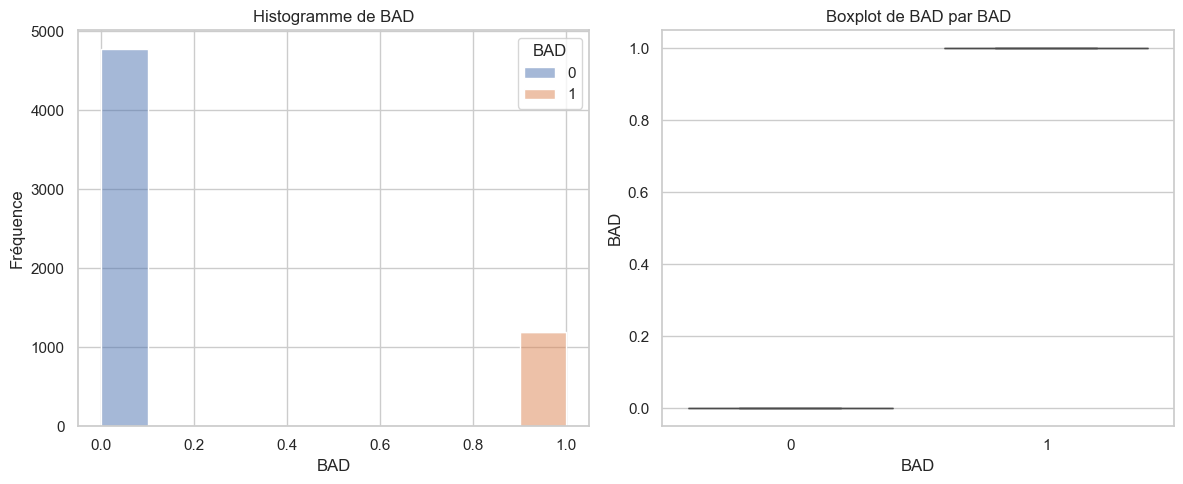

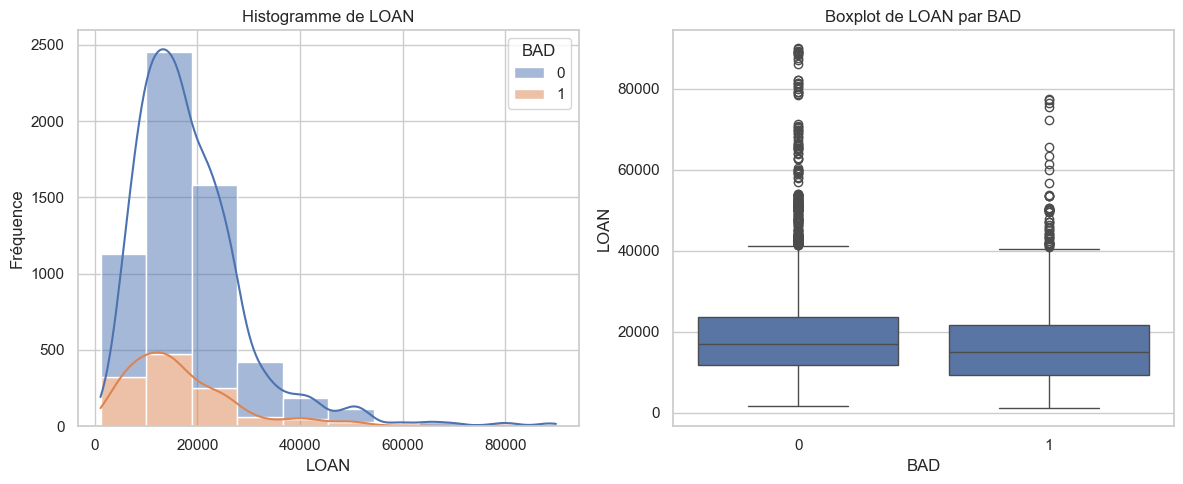

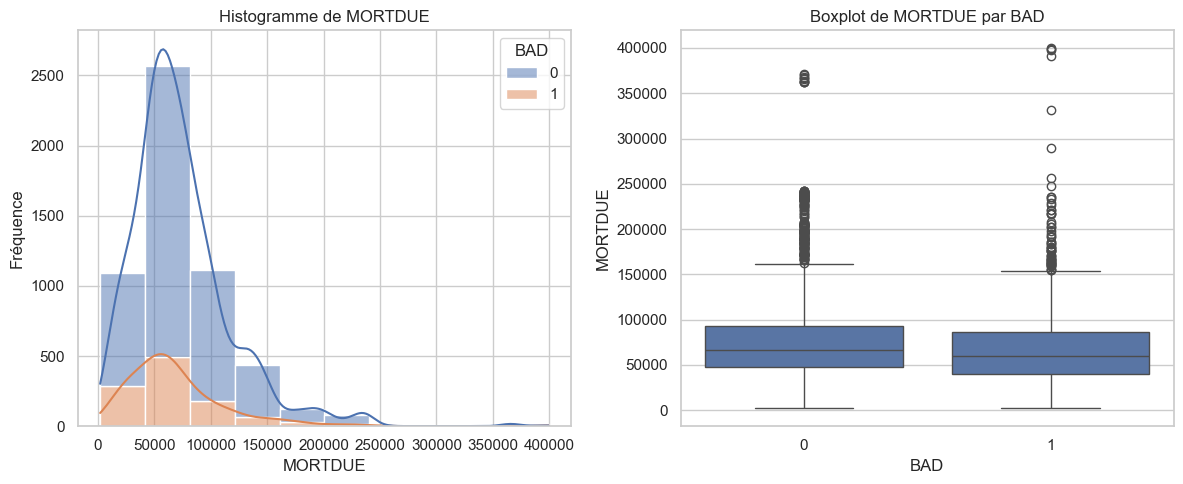

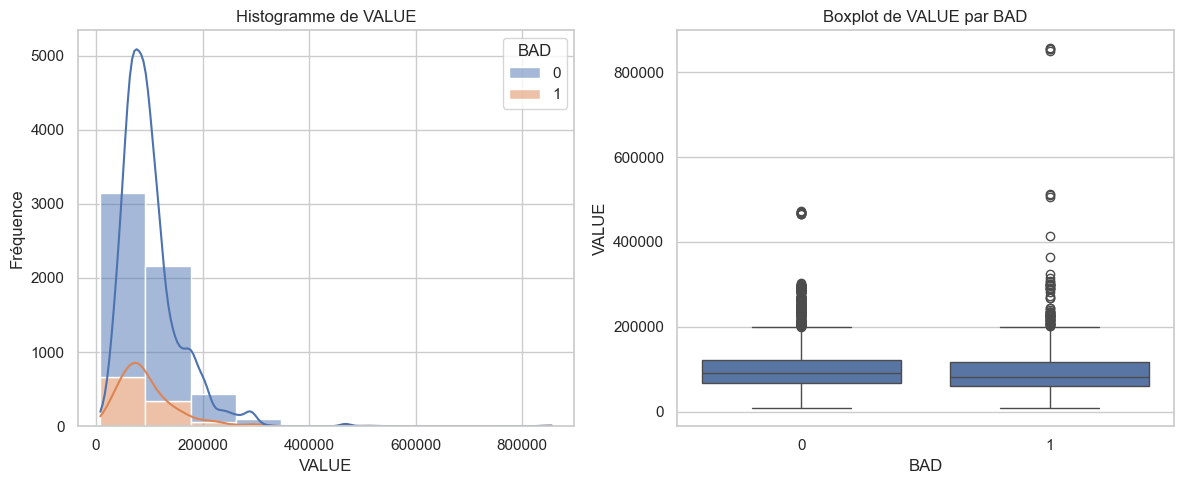

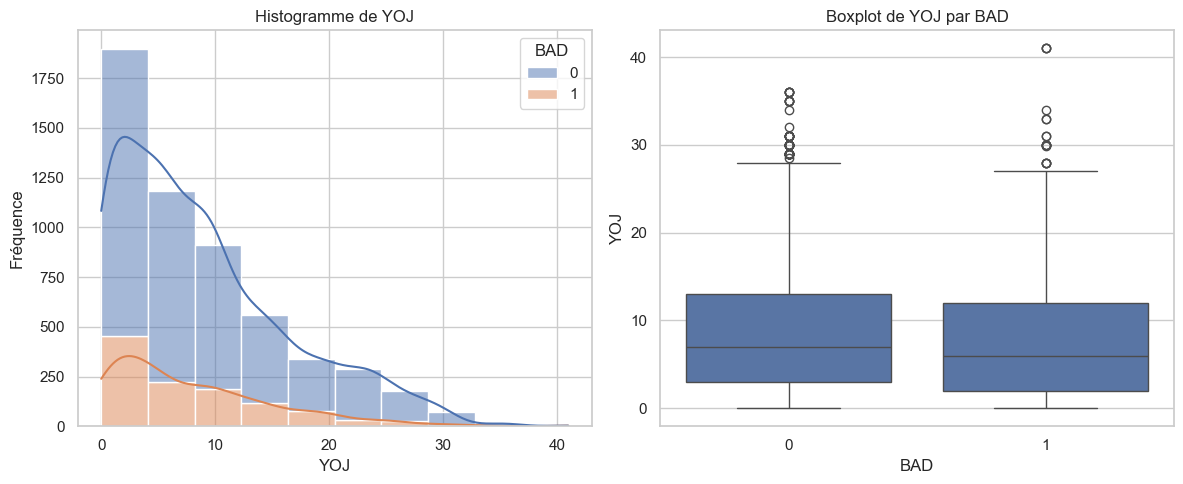

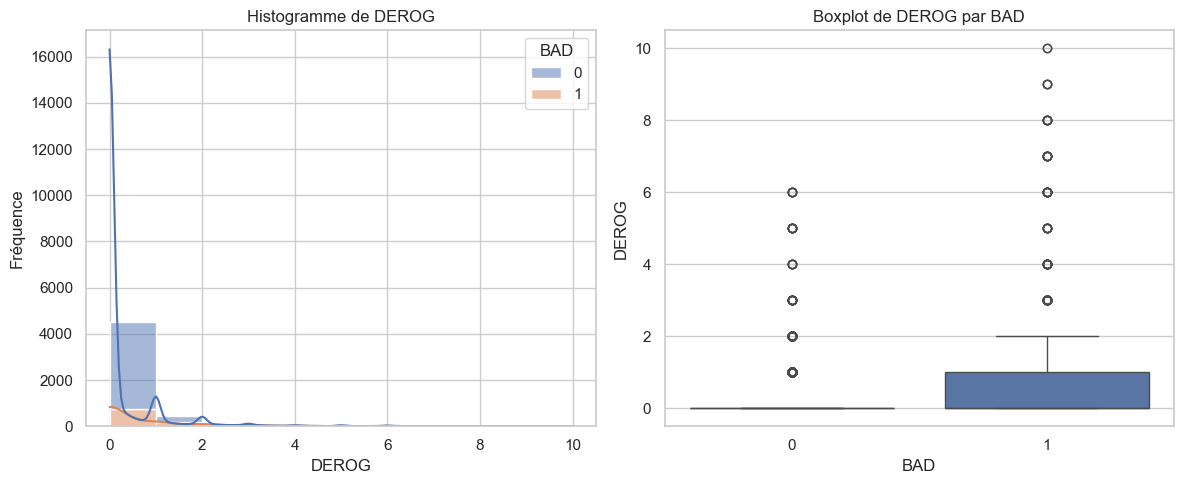

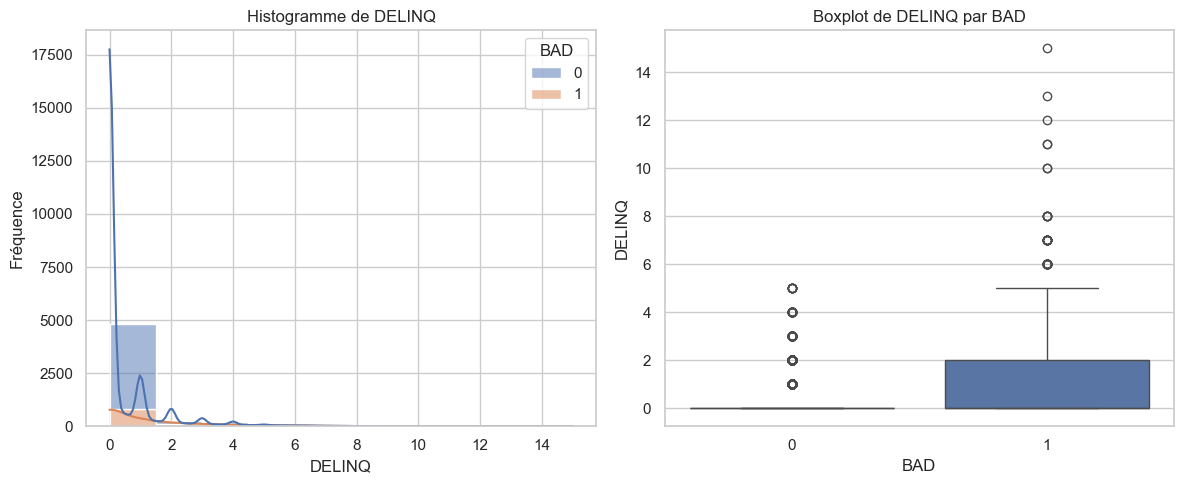

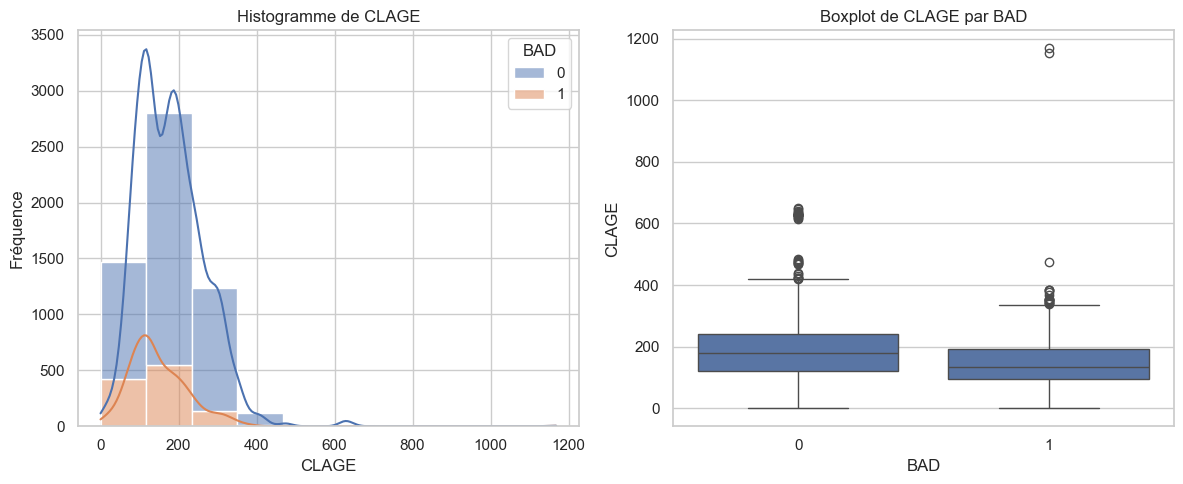

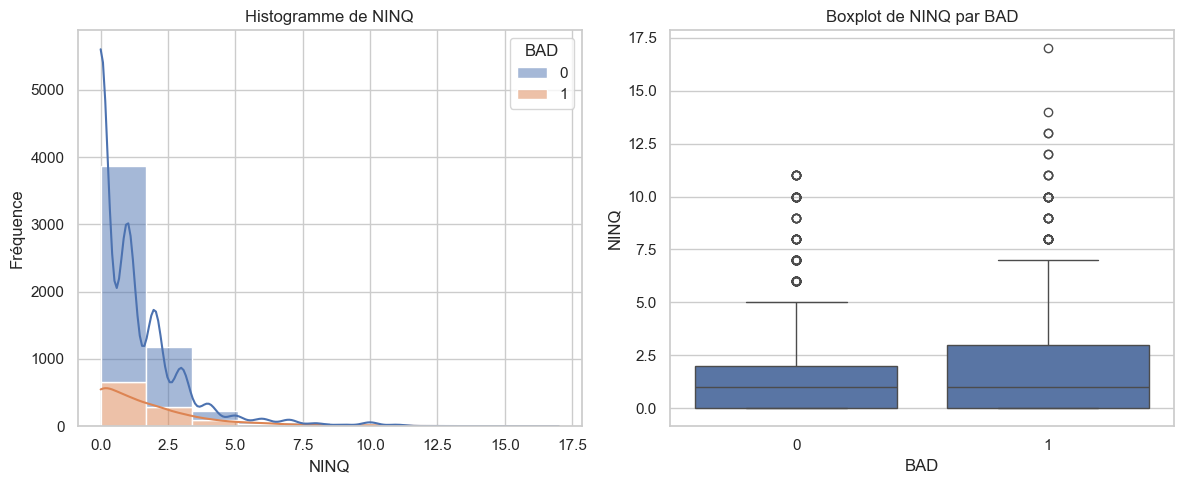

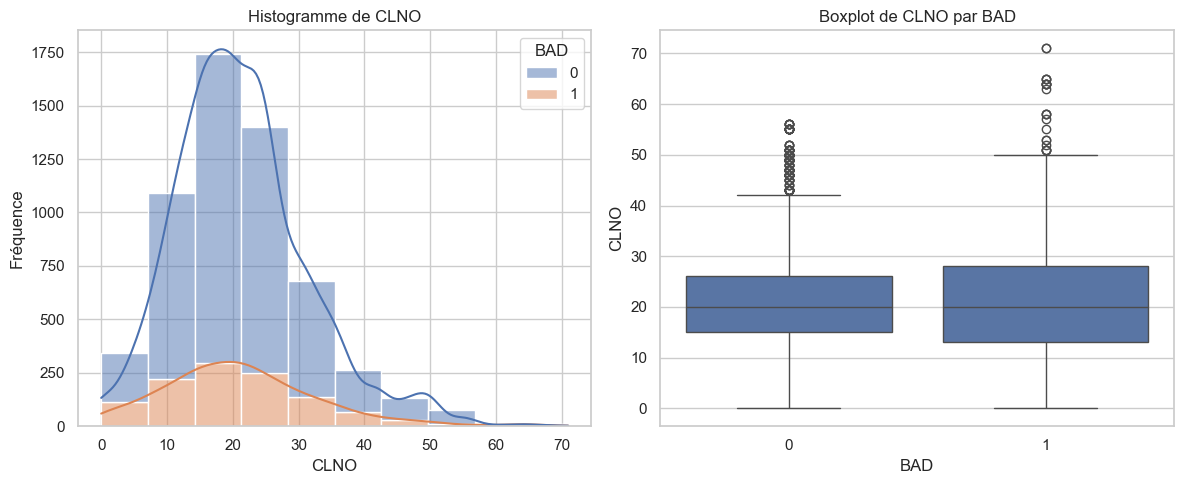

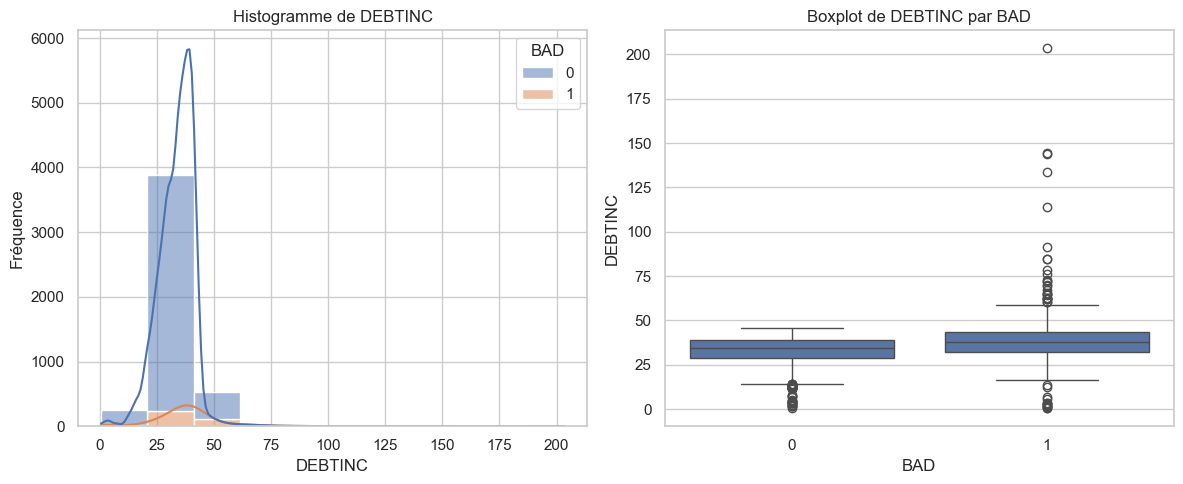

In [ ]:
# Distribution des variables en fonction de la target
sns.set(style="whitegrid")

# Tracer un histogramme et un boxplot pour chaque variable numérique
for feature in var_num:
    plt.figure(figsize=(12, 5))

    # Histogramme
    plt.subplot(1, 2, 1)
    sns.histplot(df_train, x=feature, hue=df_train['BAD'], multiple="stack", bins=10, kde=True)
    plt.title(f'Histogramme de {feature}')
    plt.xlabel(feature)
    plt.ylabel('Fréquence')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_train['BAD'], y=feature, data=df_train)
    plt.title(f'Boxplot de {feature} par BAD')
    plt.xlabel('BAD')
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

## Analyse Bivariée - Variables Catégoriques

### Analyse des Variables Catégoriques

#### Concepts:
- **Variable Catégorique**: Variable qui prend un nombre limité de valeurs distinctes
- **Distribution de fréquence**: Compte le nombre d'observations pour chaque catégorie

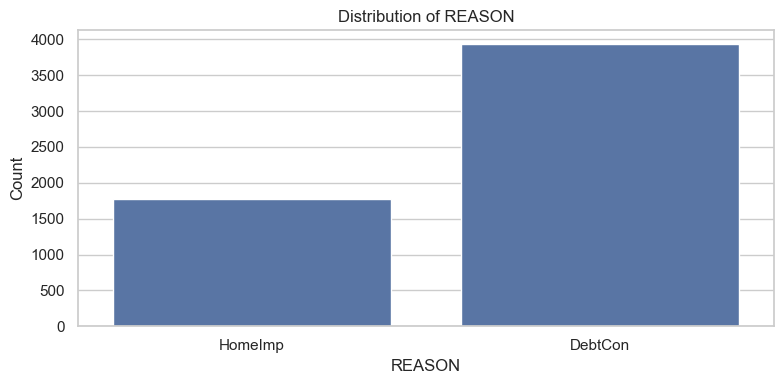

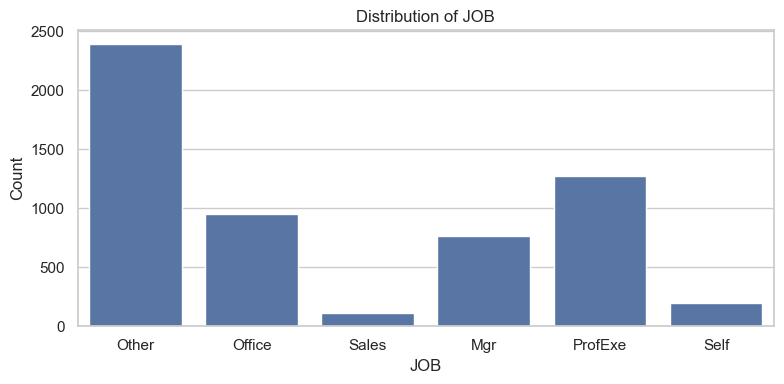

In [ ]:
# display distribution of categorical variables
for col in var_cat.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=var_cat[col])
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

### Variables Catégoriques vs Cible

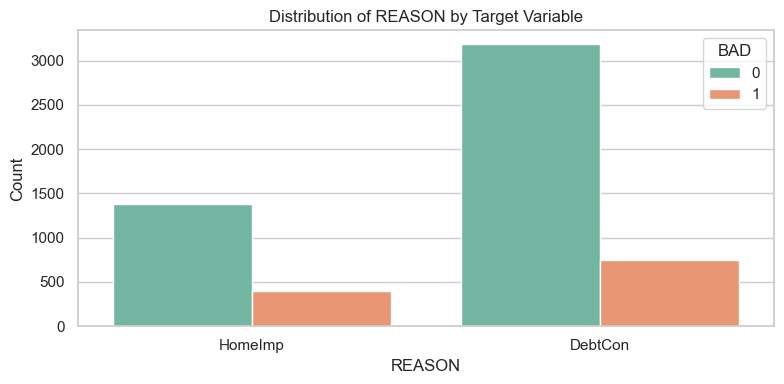

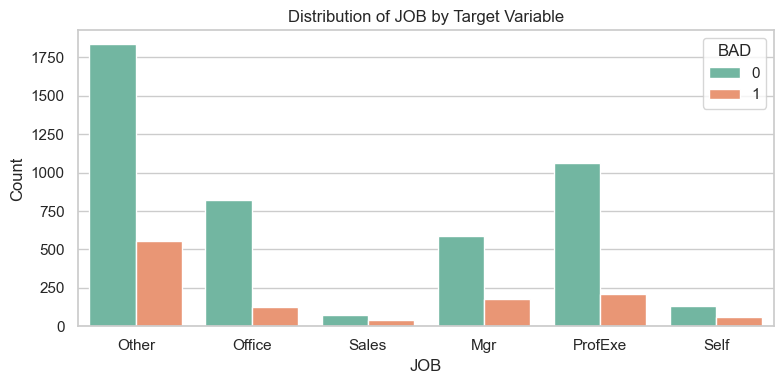

In [ ]:
# display target vs categorical variables
for col in var_cat.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=var_cat[col], hue=df_train['BAD'], palette='Set2')
    plt.title(f'Distribution of {col} by Target Variable')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

## Tests Statistiques d'Indépendance

### Test ANOVA 

**Règle de décision:**
- Si **p-value < 0.05** → **Rejeter H₀** → Les groupes ont des moyennes significativement **différentes**
- Si **p-value ≥ 0.05** → **Ne pas rejeter H₀** → Les groupes ont des moyennes similaires

**Interprétation pour la classification:**
- Variable avec p-value < 0.05 → Variable discriminante 
- Variable avec p-value ≥ 0.05 → Variable non-discriminante

In [ ]:
# ANOVA test for categorical variables vs target variable


anova_cat_results = []

for col in var_cat.columns:
    # Get unique categories
    categories = df_train[col].unique()
    
    # Create groups for each category
    groups = []
    for cat in categories:
        # Get target values for this category
        group_values = df_train['BAD'][df_train[col] == cat].values
        groups.append(group_values)
    
    try:
        # Perform ANOVA test
        f_stat, p_value = f_oneway(*groups)
        
        # Determine significance
        is_significant = "Yes" if p_value < 0.05 else "No"
        
        anova_cat_results.append([col, f_stat, p_value, is_significant])
    except Exception as e:
        anova_cat_results.append([col, np.nan, np.nan, "Error"])

# Create results DataFrame
anova_cat_df = pd.DataFrame(anova_cat_results, columns=["Variable", "F_statistic", "p_value", "Significant_0.05"])
anova_cat_df = anova_cat_df.sort_values('p_value')

anova_cat_df


c:\Users\CYTech Student\anaconda3\envs\mon_env\Lib\site-packages\scipy\stats\_stats_py.py:4133: DegenerateDataWarning: at least one input has length 0
  warnings.warn(stats.DegenerateDataWarning('at least one input '


,Variable,F_statistic,p_value,Significant_0.05
0,REASON,NaN,NaN,No
1,JOB,NaN,NaN,No


### Test du Chi-Carré (χ²) - Variables Catégoriques vs Cible

#### Théorème (Test du Chi-Carré d'Indépendance):

Le **Chi-carré** teste l'indépendance entre deux variables catégoriques.

**Hypothèses du test:**
- **H₀**: Les deux variables sont **indépendantes** (pas de relation)
- **H₁**: Les deux variables sont **associées** (relation existe)

In [ ]:
# Chi-square test for categorical variables vs target variable

chi2_results = []

for col in var_cat.columns:
    # Create contingency table
    contingency_table = pd.crosstab(df_train[col], df_train['BAD'])
    
    try:
        # Perform chi-square test
        chi2_stat, p_value, dof, expected_freq = chi2_contingency(contingency_table)
        
        # Determine significance
        is_significant = "Yes" if p_value < 0.05 else "No"
        
        chi2_results.append([col, chi2_stat, p_value, dof, is_significant])
    except Exception as e:
        chi2_results.append([col, np.nan, np.nan, np.nan, "Error"])

# Create results DataFrame
chi2_df = pd.DataFrame(chi2_results, columns=["Variable", "Chi2_statistic", "p_value", "DOF", "Significant_0.05"])
chi2_df = chi2_df.sort_values('p_value')

chi2_df


,Variable,Chi2_statistic,p_value,DOF,Significant_0.05
1,JOB,81.932490,3.306676e-16,5,Yes
0,REASON,8.039751,4.576182e-03,1,Yes


### Test Chi-Carré entre Variables Catégoriques

#### Analyse de Multicolinéarité Catégorique:

**Objectif**: Identifier les **redondances** entre variables catégoriques

**Interprétation:**
- **p-value < 0.05**: Variables sont **liées** 
- **p-value ≥ 0.05**: Variables sont **indépendantes**


In [ ]:
# Chi-square test between categorical variables

chi2_cat_results = []
cat_cols = list(var_cat.columns)

# Test all pairs of categorical variables
for col1, col2 in itertools.combinations(cat_cols, 2):
    contingency_table = pd.crosstab(df_train[col1], df_train[col2])
    
    try:
        # Perform chi-square test
        chi2_stat, p_value, dof, expected_freq = chi2_contingency(contingency_table)
        
        # Determine significance
        is_significant = "Yes" if p_value < 0.05 else "No"
        
        chi2_cat_results.append([f"{col1} vs {col2}", chi2_stat, p_value, dof, is_significant])
    except Exception as e:
        chi2_cat_results.append([f"{col1} vs {col2}", np.nan, np.nan, np.nan, "Error"])

# Create results DataFrame
chi2_cat_df = pd.DataFrame(chi2_cat_results, columns=["Variable Pair", "Chi2_statistic", "p_value", "DOF", "Significant_0.05"])
chi2_cat_df = chi2_cat_df.sort_values('p_value')

chi2_cat_df


,Variable Pair,Chi2_statistic,p_value,DOF,Significant_0.05
0,REASON vs JOB,122.908575,7.594351e-25,5,Yes


In [ ]:
# save the new dataset
#df_train.to_csv('../data/cleaned_data.csv', index=False)